In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path

# consistent style throughout
plt.rcParams.update({
    "figure.dpi": 120,
    "figure.figsize": (12, 4),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

DATA = Path("../data/processed/merged.parquet")

In [21]:
df = pd.read_parquet(DATA)

print(f"Shape: {df.shape}")
print(f"Buildings: {df['building_id'].nunique()}")
print(f"Sites: {df['site_id'].nunique()}")
print(f"Date range: {df['timestamp'].min()} → {df['timestamp'].max()}")
print(f"\nMeter types:\n{df['meter_type'].value_counts()}")
print(f"\nBuilding use:\n{df['primaryspaceusage'].value_counts()}")
print(f"\nQuality flags:\n{df['quality_flag'].value_counts()}")
# print(f"\nNull counts:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
print(f"\nNull counts:\n{df.isnull().sum()}")

Shape: (7631640, 26)
Buildings: 435
Sites: 9
Date range: 2016-01-01 00:00:00+00:00 → 2017-12-31 23:00:00+00:00

Meter types:
meter_type
electricity    7631640
Name: count, dtype: int64

Building use:
primaryspaceusage
Education    4561440
Office       3070200
Name: count, dtype: int64

Quality flags:
quality_flag
ok    7631640
Name: count, dtype: int64

Null counts:
timestamp                  0
building_id                0
meter_reading         193275
meter_type                 0
quality_flag               0
primaryspaceusage          0
sqm                        0
yearbuilt            5333376
timezone                   0
numberoffloors       7350936
site_id                    0
temp_c                 22030
cloud_coverage       3519663
dew_temp_c             30403
precip_1hr_mm        1019329
precip_6hr_mm        7298195
sea_lvl_pressure      200924
wind_direction        575624
wind_speed_ms          43447
hour                       0
day_of_week                0
month                 

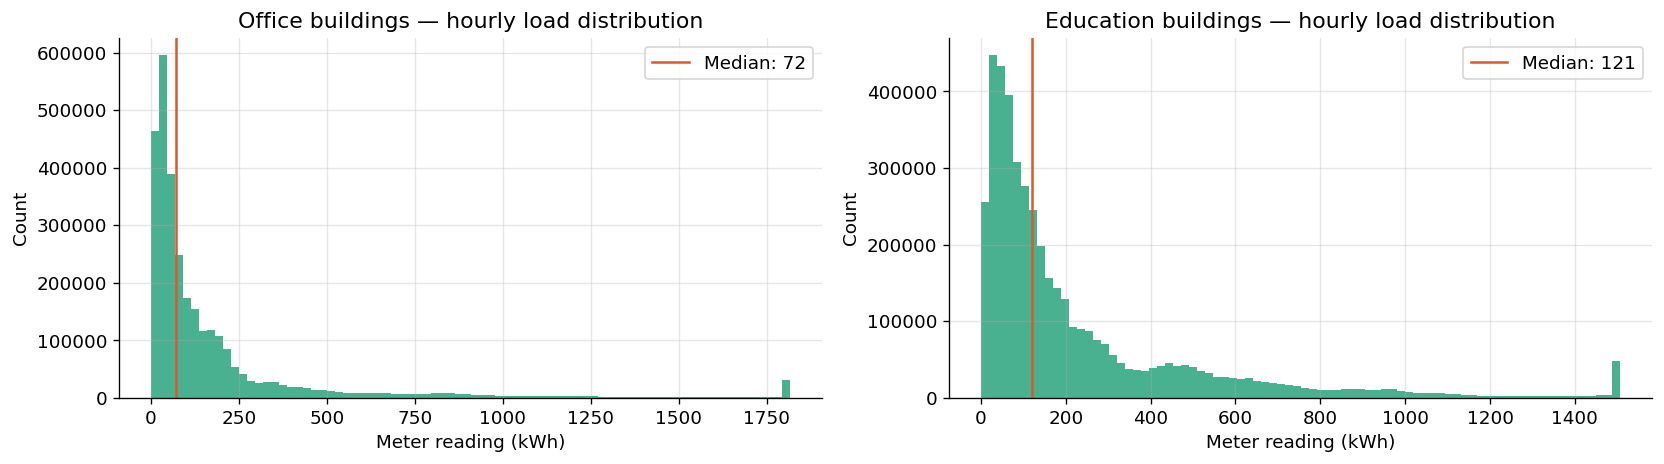

Plot 1 saved


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, use in zip(axes, ["Office", "Education"]):
    subset = df[df["primaryspaceusage"] == use]["meter_reading"]
    # clip top 1% to avoid extreme outliers dominating the axis
    cap = subset.quantile(0.99)
    subset = subset.clip(upper=cap)
    ax.hist(subset, bins=80, color="#1D9E75", alpha=0.8, edgecolor="none")
    ax.set_title(f"{use} buildings — hourly load distribution")
    ax.set_xlabel("Meter reading (kWh)")
    ax.set_ylabel("Count")
    ax.axvline(subset.median(), color="#D85A30", linewidth=1.5,
               label=f"Median: {subset.median():.0f}")
    ax.legend()

plt.tight_layout()
plt.savefig("../data/processed/plot_01_load_distribution.png", bbox_inches="tight")
plt.show()
print("Plot 1 saved")

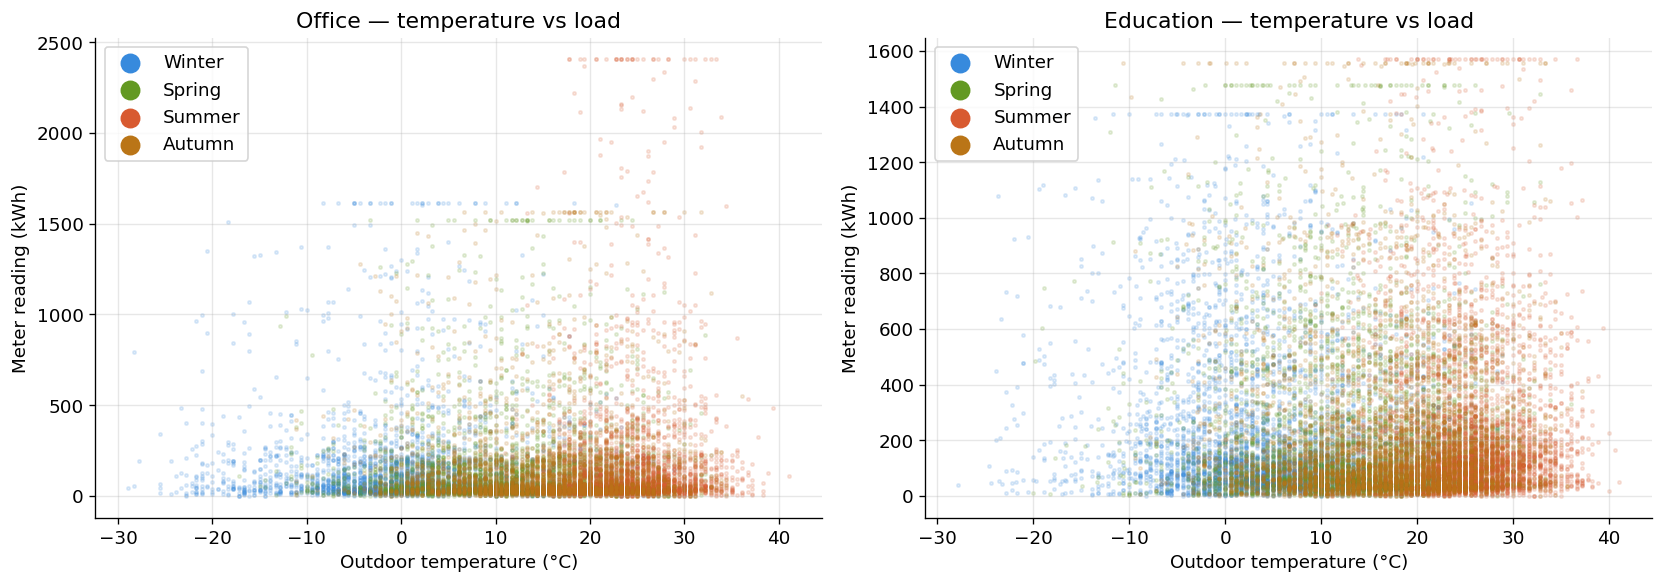

Plot 2 saved


In [23]:
# sample to keep scatter readable
sample = df[df["primaryspaceusage"].isin(["Office", "Education"])].sample(
    n=min(30_000, len(df)), random_state=42
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

season_map = {12: "Winter", 1: "Winter", 2: "Winter",
              3: "Spring", 4: "Spring", 5: "Spring",
              6: "Summer", 7: "Summer", 8: "Summer",
              9: "Autumn", 10: "Autumn", 11: "Autumn"}
season_colors = {"Winter": "#378ADD", "Spring": "#639922",
                 "Summer": "#D85A30", "Autumn": "#BA7517"}

sample["season"] = sample["month"].map(season_map)

for ax, use in zip(axes, ["Office", "Education"]):
    sub = sample[sample["primaryspaceusage"] == use]
    for season, color in season_colors.items():
        s = sub[sub["season"] == season]
        ax.scatter(s["temp_c"], s["meter_reading"].clip(upper=s["meter_reading"].quantile(0.99)),
                   alpha=0.15, s=4, color=color, label=season)
    ax.set_title(f"{use} — temperature vs load")
    ax.set_xlabel("Outdoor temperature (°C)")
    ax.set_ylabel("Meter reading (kWh)")
    handles = [plt.scatter([], [], color=c, label=s, s=30)
               for s, c in season_colors.items()]
    ax.legend(handles=handles, markerscale=2)

plt.tight_layout()
plt.savefig("../data/processed/plot_02_temp_vs_load.png", bbox_inches="tight")
plt.show()
print("Plot 2 saved")

Using building: Hog_office_Almeda
Anomalous week: 2016-09-12 → 2016-09-18


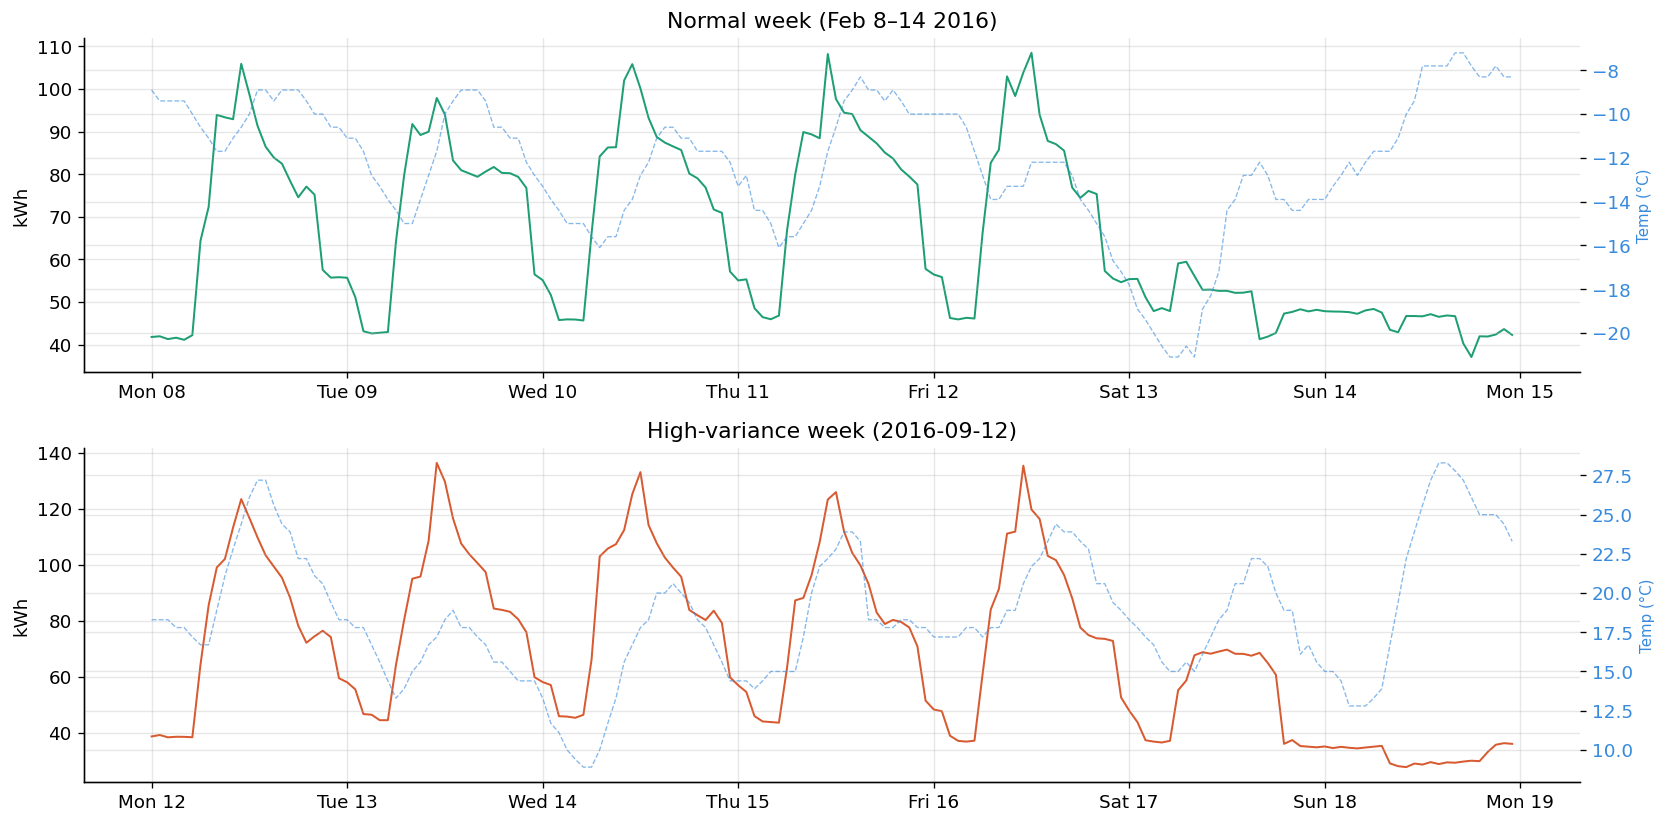

Plot 3 saved


In [24]:
# pick one well-covered office building
building = (
    df[df["primaryspaceusage"] == "Office"]
    .groupby("building_id")["meter_reading"]
    .apply(lambda x: x.notna().mean())
    .idxmax()
)
print(f"Using building: {building}")

bdf = df[df["building_id"] == building].set_index("timestamp").sort_index()

# normal week — mid February 2016 (cold, typical)
normal_start = "2016-02-08"
normal_end   = "2016-02-14"

# anomalous week — find the week with highest variance
bdf = (
    df[(df["building_id"] == building) & (df["meter_type"] == "electricity")]
    .set_index("timestamp")
    .sort_index()
    .drop_duplicates()
)

# group by week using the index directly — no need for a "week" column
weekly_std = bdf["meter_reading"].resample("W").std()
anomalous_week_end = weekly_std.idxmax()  # resample("W") labels by week-end date
anomalous_start = str((anomalous_week_end - pd.Timedelta(days=6)).date())
anomalous_end = str(anomalous_week_end.date())
print(f"Anomalous week: {anomalous_start} → {anomalous_end}")

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=False)

for ax, (start, end), label, color in zip(
    axes,
    [(normal_start, normal_end), (anomalous_start, anomalous_end)],
    ["Normal week (Feb 8–14 2016)", f"High-variance week ({anomalous_start})"],
    ["#1D9E75", "#D85A30"]
):
    week = bdf[start:end]
    ax.plot(week.index, week["meter_reading"], color=color, linewidth=1.2)
    ax2 = ax.twinx()
    ax2.plot(week.index, week["temp_c"], color="#378ADD",
             linewidth=0.8, linestyle="--", alpha=0.6)
    ax2.set_ylabel("Temp (°C)", color="#378ADD", fontsize=9)
    ax2.tick_params(axis="y", labelcolor="#378ADD")
    ax.set_title(label)
    ax.set_ylabel("kWh")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%a %d"))

plt.tight_layout()
plt.savefig("../data/processed/plot_03_normal_vs_anomalous.png", bbox_inches="tight")
plt.show()
print("Plot 3 saved")

Pivot shape: (40, 24)
Pivot null rate: 0.00
Pivot value range: 0.000 → 0.003


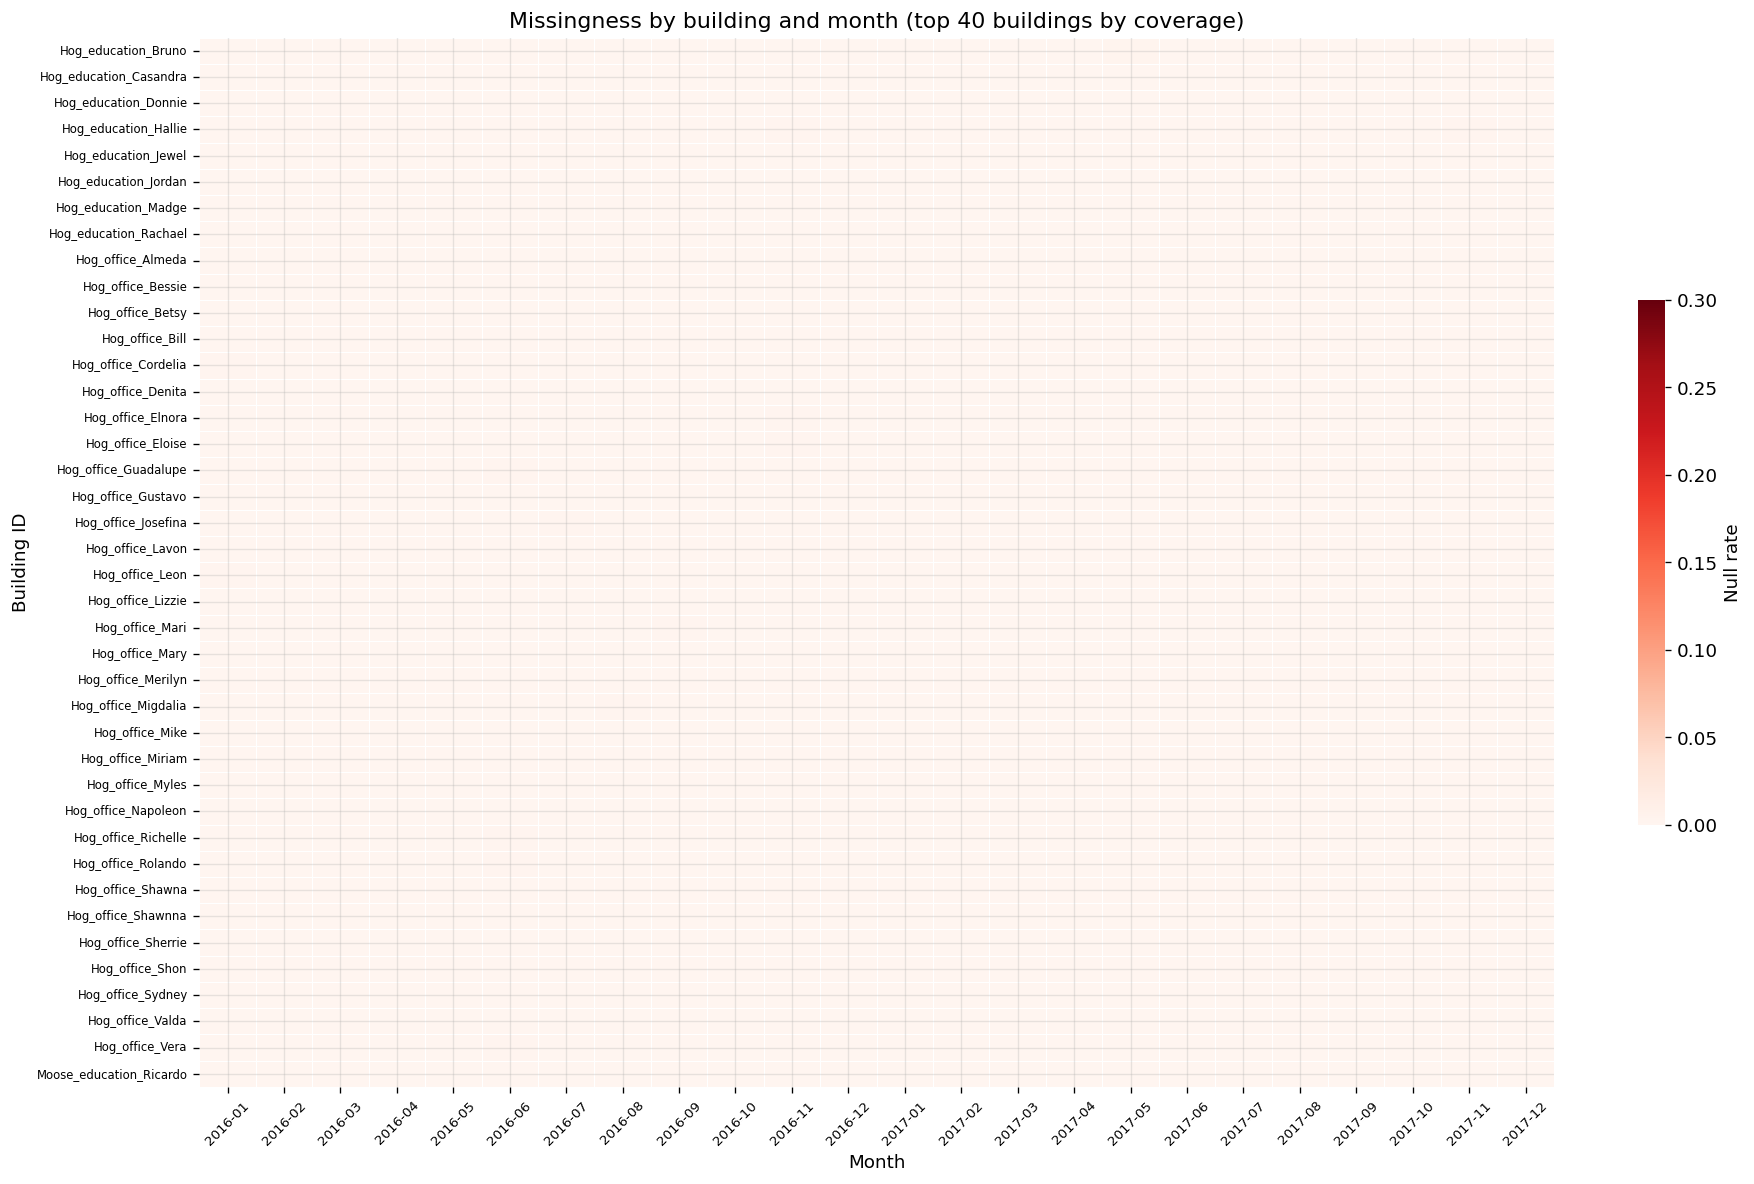

In [28]:
monthly = (
    df[df["primaryspaceusage"].isin(["Office", "Education"])]
    .copy()
)
monthly["year_month"] = monthly["timestamp"].dt.strftime("%Y-%m")

top_buildings = (
    monthly.groupby("building_id")["meter_reading"]
    .count()
    .nlargest(40)
    .index
)

pivot = (
    monthly[monthly["building_id"].isin(top_buildings)]
    .groupby(["building_id", "year_month"])["meter_reading"]
    .apply(lambda x: x.isna().mean())
    .unstack(fill_value=0)  # fill missing combos with 0 instead of NaN
)

print(f"Pivot shape: {pivot.shape}")
print(f"Pivot null rate: {pivot.isna().mean().mean():.2f}")
print(f"Pivot value range: {pivot.min().min():.3f} → {pivot.max().max():.3f}")

fig, ax = plt.subplots(figsize=(16, 10))
sns.heatmap(
    pivot,
    ax=ax,
    cmap="Reds",
    vmin=0, vmax=0.3,
    linewidths=0.3,
    linecolor="white",
    cbar_kws={"label": "Null rate", "shrink": 0.5},
)
ax.set_title("Missingness by building and month (top 40 buildings by coverage)")
ax.set_xlabel("Month")
ax.set_ylabel("Building ID")
ax.tick_params(axis="x", rotation=45, labelsize=8)
ax.tick_params(axis="y", labelsize=7)

plt.tight_layout()
plt.savefig("../data/processed/plot_04_missingness.png", bbox_inches="tight")
plt.show()

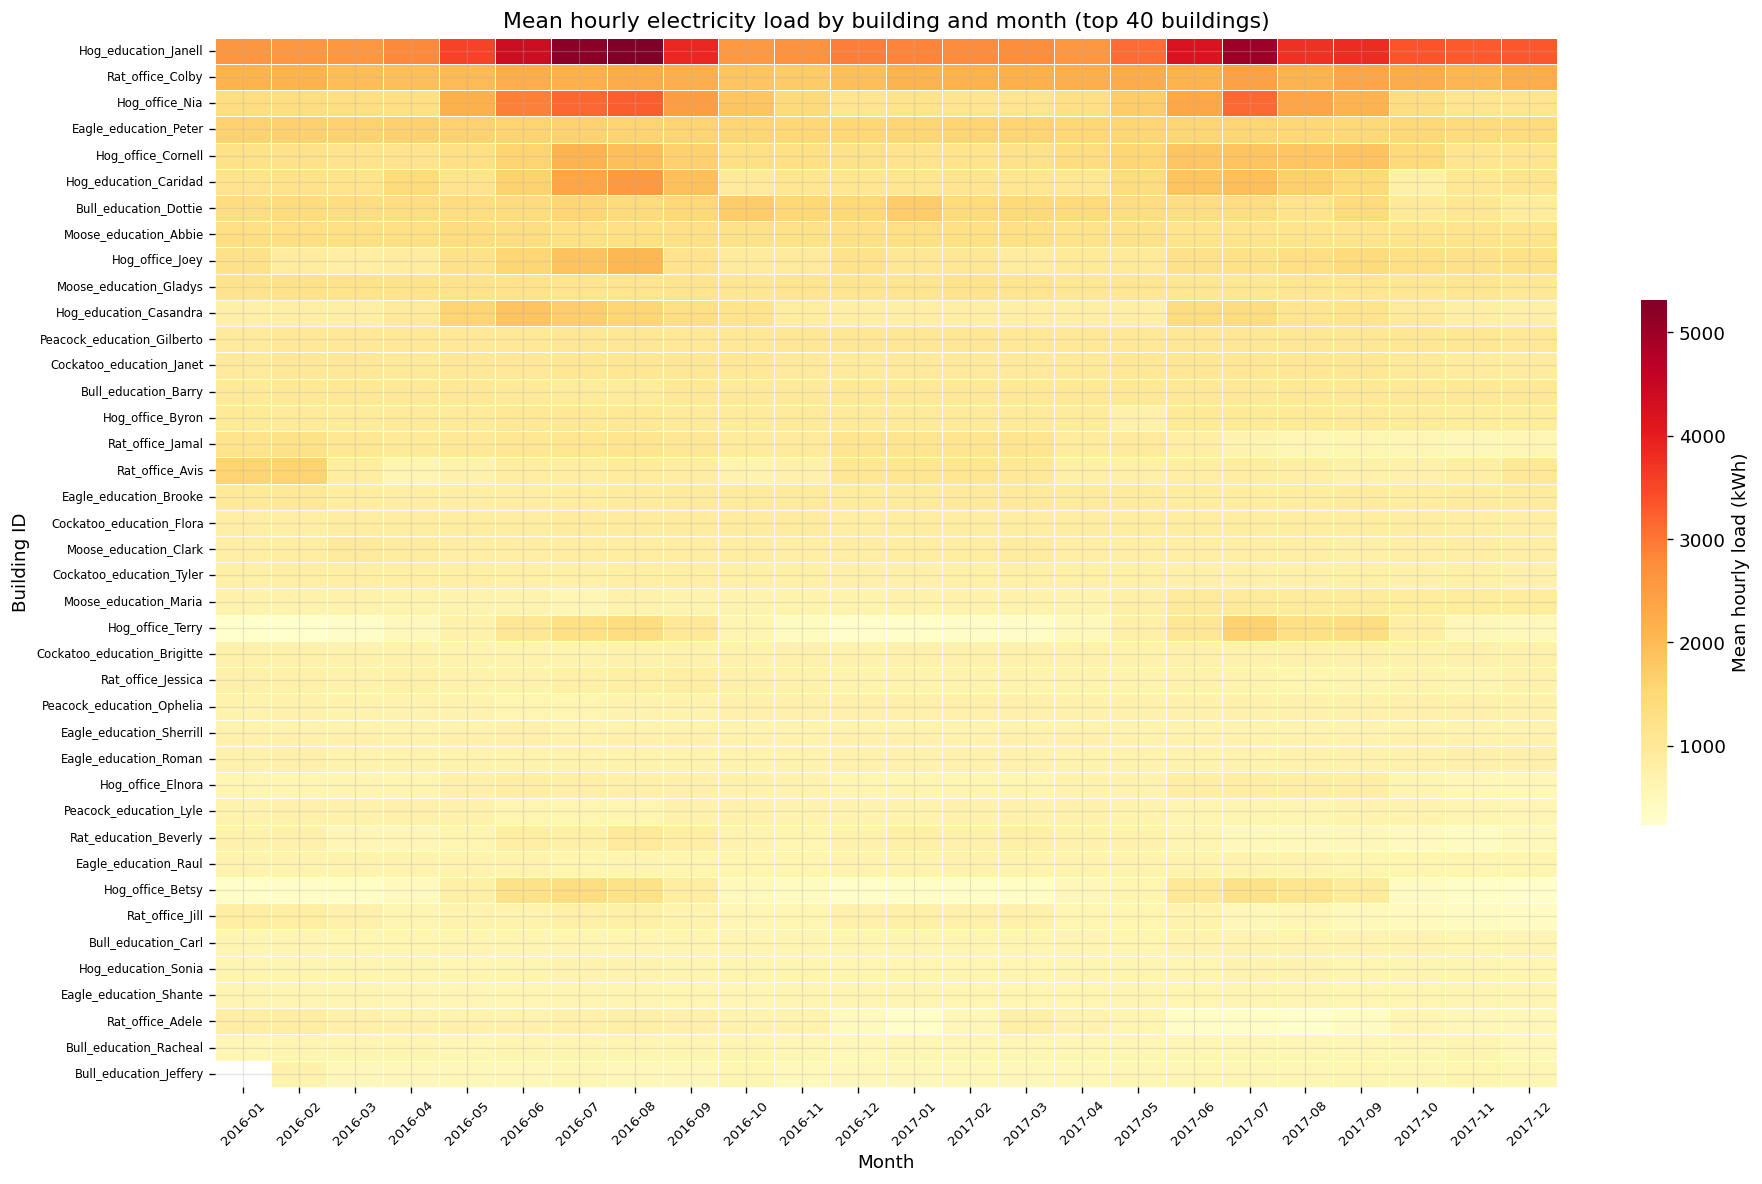

In [34]:
top_buildings_by_meter = (
    monthly.groupby("building_id")["meter_reading"]
    .mean()  # or .sum() — sum favors buildings with more hours, mean is fairer
    .nlargest(40)
    .index
)

pivot = (
    monthly[monthly["building_id"].isin(top_buildings_by_meter)]
    .groupby(["building_id", "year_month"])["meter_reading"]
    .mean()
    .unstack(fill_value=0)
)

# sort rows by mean load across all months
pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(16, 10))
sns.heatmap(
    pivot,
    ax=ax,
    cmap="YlOrRd",
    linewidths=0.3,
    linecolor="white",
    cbar_kws={"label": "Mean hourly load (kWh)", "shrink": 0.5},
)
ax.set_title("Mean hourly electricity load by building and month (top 40 buildings)")
ax.set_xlabel("Month")
ax.set_ylabel("Building ID")
ax.tick_params(axis="x", rotation=45, labelsize=8)
ax.tick_params(axis="y", labelsize=7)

plt.tight_layout()
plt.savefig("../data/processed/plot_04_load_heatmap.png", bbox_inches="tight")
plt.show()

## Key findings

**Dataset:** 435 buildings (307 Office, 617 Education sites across all timezones),
7.6M hourly electricity readings across 2016–2017. After filtering to US/Eastern
and US/Central Office and Education buildings, working subset is X buildings.

**Load distribution:** Office buildings show a tighter load distribution than
Education buildings, which have higher variance likely driven by campus-scale
variation in building size and occupancy patterns.

**Temperature relationship:** A clear U-shaped relationship between outdoor
temperature and electricity load — loads are elevated in both winter (heating
ventilation) and summer (cooling), with a trough around 15–18°C. This validates
HDD and CDD as strong candidate features.

**Anomalies:** High-variance weeks correspond to [describe what you find —
holiday shutdowns, sensor faults, etc.]. These are flagged with `quality_flag =
suspect_zero` in the pipeline.

**Missingness:** Most buildings have <5% null rate. A small number show extended
gaps — these will be excluded from the modeling subset via the MIN_COVERAGE
filter already applied in ingestion.

**Next step:** Feature engineering and baseline model (XGBoost) in phase 2.